# Angie Crews Notebook
## P3: Text Exploration

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

- Author: [Angie Crews](https://github.com/Angie-Crews)
- Repository: [nlp-03-text-exploration](https://github.com/Angie-Crews/nlp-03-text-exploration)
- Date: 2026-03-25

Purpose

Perform exploratory analysis of a small, controlled text corpus.
Demonstrate how structure emerges from token distributions,
category comparisons, and co-occurrence patterns.

Analytical Questions

- What tokens dominate each category after removing common stopwords?
- How do categories differ in vocabulary?
- What words appear in similar contexts?
- What structure is visible before using any models?

Notes

- This notebook focuses on exploratory analysis (EDA), not modeling.
- Phase 4 modification: remove common stopwords before the main analysis tables and save the chart output.

Project Instructions

- See [docs/project-instructions.md](../docs/project-instructions.md)
- See [docs/glossary.md](../docs/glossary.md)

## Terminology

In preparation for large language models and related methods, our analysis does not begin with semantic interpretation.
Instead, we focus on **proximity** and observable **patterns** in the text.

We evaluate **co-occurrence (context windows)**,
that is, _which words tend to appear near each other_.

The full collection of text is called a **corpus** (a set of documents).
For this analysis, each document is represented as a single line of text.

## Section 0. How to Use This Notebook

This notebook explores a small labeled corpus using token frequencies, category comparisons, co-occurrence, bigrams, and a saved visualization.

Before running:
- Select the project `.venv` kernel
- Run the cells from top to bottom
- Review the saved chart in `docs/images` if you want the exported file after execution

Phase 4 focus:
- Remove common stopwords before the main analysis
- Compare category-specific terms more clearly
- Display the chart inline in the notebook and save a copy to disk

## Section 1. Setup and Imports

Imports and configuration appear once, at the top.

In [42]:
# Section 1 Python cell

from collections import defaultdict
import logging
from pathlib import Path

from datafun_toolkit.logger import get_logger, log_header, log_path
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import polars as pl

print("Imports complete.")

Imports complete.


### Configure Logger and Paths

In [43]:
# Section 1 Python cell (logger configuration and path setup)

LOG: logging.Logger = get_logger("CI", level="DEBUG")

NOTEBOOKS_PATH: Path = Path.cwd()
ROOT_PATH: Path = NOTEBOOKS_PATH.parent
SCRIPTS_PATH: Path = ROOT_PATH / "scripts"
PLOTS_PATH: Path = ROOT_PATH / "docs" / "images"
BIGRAM_PLOT_FILE_PATH: Path = PLOTS_PATH / "nlp_corpus_explore_crews_p4_top_bigrams.png"
PLOT_FILE_PATH: Path = PLOTS_PATH / "nlp_corpus_explore_crews_p4_top_tokens.png"

log_header(LOG, "MODULE 3 NOTEBOOK: CORPUS EXPLORATION")

log_path(LOG, "ROOT_PATH", ROOT_PATH)
log_path(LOG, "NOTEBOOKS_PATH", NOTEBOOKS_PATH)
log_path(LOG, "SCRIPTS_PATH", SCRIPTS_PATH)
log_path(LOG, "PLOTS_PATH", PLOTS_PATH)
log_path(LOG, "BIGRAM_PLOT_FILE_PATH", BIGRAM_PLOT_FILE_PATH)

LOG.info("Logger configured.")

2026-03-25 18:13:50 | INFO | CI | === RUN START ===
2026-03-25 18:13:50 | INFO | CI | project=MODULE 3 NOTEBOOK: CORPUS EXPLORATION
2026-03-25 18:13:50 | INFO | CI | repo_dir=nlp-03-text-exploration
2026-03-25 18:13:50 | INFO | CI | python=3.14.3
2026-03-25 18:13:50 | INFO | CI | os=Windows 11
2026-03-25 18:13:50 | INFO | CI | shell=powershell
2026-03-25 18:13:50 | INFO | CI | cwd=notebooks
2026-03-25 18:13:50 | INFO | CI | github_actions=False
2026-03-25 18:13:50 | INFO | CI | ROOT_PATH = .
2026-03-25 18:13:50 | INFO | CI | NOTEBOOKS_PATH = notebooks
2026-03-25 18:13:50 | INFO | CI | SCRIPTS_PATH = scripts
2026-03-25 18:13:50 | INFO | CI | PLOTS_PATH = docs\images
2026-03-25 18:13:50 | INFO | CI | BIGRAM_PLOT_FILE_PATH = docs\images\nlp_corpus_explore_crews_p4_top_bigrams.png
2026-03-25 18:13:50 | INFO | CI | Logger configured.


## Section 2. Define Corpus (Labeled Text Documents)

In [44]:
# Section 2 Python cell

# A corpus is a collection of text documents.
# Each document is associated with a category label.
# Use a list of dictionaries to represent the corpus in memory.
# A dictionary uses labeled key:value pairs.
# Key:value pairs let us store the category and the text together.

corpus = [
    {"category": "dog", "text": "A dog barks loudly."},
    {"category": "dog", "text": "The puppy runs in the yard."},
    {"category": "dog", "text": "A canine wears a leash."},
    {"category": "dog", "text": "The kennel holds the dog."},
    {"category": "dog", "text": "The dog ran across the yard."},
    {"category": "dog", "text": "The puppy ran across the yard."},
    {"category": "cat", "text": "A cat sleeps quietly."},
    {"category": "cat", "text": "The kitten plays with yarn."},
    {"category": "cat", "text": "A feline purrs softly."},
    {"category": "cat", "text": "The cat has whiskers."},
    {"category": "cat", "text": "The cat slept near the window."},
    {"category": "cat", "text": "The kitten slept near the window."},
    {"category": "car", "text": "A car drives on the road."},
    {"category": "car", "text": "The sedan parks in the garage."},
    {"category": "car", "text": "A vehicle has four wheels."},
    {"category": "car", "text": "The car moves down the highway."},
    {"category": "car", "text": "The car stopped near the garage."},
    {"category": "car", "text": "The sedan stopped near the garage."},
    {"category": "truck", "text": "A truck carries cargo."},
    {"category": "truck", "text": "The pickup pulls a trailer."},
    {"category": "truck", "text": "The engine powers the truck."},
    {"category": "truck", "text": "The truck hauls heavy loads."},
]

print(f"Corpus contains {len(corpus)} documents.")

Corpus contains 22 documents.


## Section 3. Tokenize and Clean Text

In [45]:
# Section 3 Python cell

# Tokenization splits text into word-like units.

STOPWORDS: set[str] = {
    "the",
    "a",
    "an",
    "in",
    "on",
    "with",
    "has",
    "down",
    "near",
}


def tokenize(text: str) -> list[str]:
    tokens = text.lower().split()
    return [t.strip(".,:;!?()[]\"'") for t in tokens if len(t) > 2]


records_list: list[dict[str, str]] = []
for doc in corpus:
    tokens = tokenize(doc["text"])
    for token in tokens:
        records_list.append({"category": doc["category"], "token": token})

token_df: pl.DataFrame = pl.DataFrame(records_list)
filtered_token_df: pl.DataFrame = token_df.filter(~pl.col("token").is_in(STOPWORDS))

print("Tokenization complete.")
print(token_df.head(10))
print(
    f"Removed {token_df.height - filtered_token_df.height} stopword tokens before analysis."
)
print(filtered_token_df.head(10))

Tokenization complete.
shape: (10, 2)
┌──────────┬────────┐
│ category ┆ token  │
│ ---      ┆ ---    │
│ str      ┆ str    │
╞══════════╪════════╡
│ dog      ┆ dog    │
│ dog      ┆ barks  │
│ dog      ┆ loudly │
│ dog      ┆ the    │
│ dog      ┆ puppy  │
│ dog      ┆ runs   │
│ dog      ┆ the    │
│ dog      ┆ yard   │
│ dog      ┆ canine │
│ dog      ┆ wears  │
└──────────┴────────┘
Removed 35 stopword tokens before analysis.
shape: (10, 2)
┌──────────┬────────┐
│ category ┆ token  │
│ ---      ┆ ---    │
│ str      ┆ str    │
╞══════════╪════════╡
│ dog      ┆ dog    │
│ dog      ┆ barks  │
│ dog      ┆ loudly │
│ dog      ┆ puppy  │
│ dog      ┆ runs   │
│ dog      ┆ yard   │
│ dog      ┆ canine │
│ dog      ┆ wears  │
│ dog      ┆ leash  │
│ dog      ┆ kennel │
└──────────┴────────┘


## Section 4. Compute Global Token Frequencies

In [46]:
# Section 4 Python cell

# Frequency distribution = how often each token appears.

global_freq_df: pl.DataFrame = (
    filtered_token_df.group_by("token").len().sort("len", descending=True)
)

print("Top global tokens:")
print(global_freq_df.head(10))

Top global tokens:
shape: (10, 2)
┌────────┬─────┐
│ token  ┆ len │
│ ---    ┆ --- │
│ str    ┆ u32 │
╞════════╪═════╡
│ cat    ┆ 3   │
│ truck  ┆ 3   │
│ dog    ┆ 3   │
│ garage ┆ 3   │
│ yard   ┆ 3   │
│ car    ┆ 3   │
│ puppy  ┆ 2   │
│ across ┆ 2   │
│ ran    ┆ 2   │
│ sedan  ┆ 2   │
└────────┴─────┘


## Section 5. Compute Token Frequencies by Category

In [47]:
# Section 5 Python cell

# Compare token usage across categories.

category_freq_df: pl.DataFrame = (
    filtered_token_df.group_by(["category", "token"])
    .len()
    .sort(["category", "len"], descending=True)
)

print("Top tokens by category:")
print(category_freq_df.head(12))

Top tokens by category:
shape: (12, 3)
┌──────────┬─────────┬─────┐
│ category ┆ token   ┆ len │
│ ---      ┆ ---     ┆ --- │
│ str      ┆ str     ┆ u32 │
╞══════════╪═════════╪═════╡
│ truck    ┆ truck   ┆ 3   │
│ truck    ┆ heavy   ┆ 1   │
│ truck    ┆ powers  ┆ 1   │
│ truck    ┆ pickup  ┆ 1   │
│ truck    ┆ pulls   ┆ 1   │
│ …        ┆ …       ┆ …   │
│ truck    ┆ loads   ┆ 1   │
│ truck    ┆ carries ┆ 1   │
│ truck    ┆ hauls   ┆ 1   │
│ truck    ┆ engine  ┆ 1   │
│ dog      ┆ dog     ┆ 3   │
└──────────┴─────────┴─────┘


## Section 6. Identify Top Tokens per Category

In [48]:
# Section 6 Python cell

# Show top tokens per category.

top_per_category_dict: dict[str, list[str]] = {}

for category in filtered_token_df["category"].unique().to_list():
    subset_df = category_freq_df.filter(pl.col("category") == category).head(5)
    top_tokens_list = subset_df["token"].to_list()
    top_per_category_dict[category] = top_tokens_list

    print(f"{category.upper()} top tokens: {top_tokens_list}")

DOG top tokens: ['dog', 'yard', 'ran', 'across', 'puppy']
CAR top tokens: ['garage', 'car', 'stopped', 'sedan', 'road']
TRUCK top tokens: ['truck', 'heavy', 'powers', 'pickup', 'pulls']
CAT top tokens: ['cat', 'slept', 'window', 'kitten', 'yarn']


## Section 7. Analyze Co-occurrence (Context Windows)

In [49]:
# Section 7 Python cell

# Co-occurrence examines which tokens appear near each other.

WINDOW_SIZE: int = 2
co_occurrence_dict: dict[str, list[str]] = defaultdict(list)

for doc in corpus:
    tokens = [token for token in tokenize(doc["text"]) if token not in STOPWORDS]
    for i, token in enumerate(tokens):
        start = max(0, i - WINDOW_SIZE)
        end = min(len(tokens), i + WINDOW_SIZE + 1)
        context = tokens[start:end]
        for ctx in context:
            if ctx != token:
                co_occurrence_dict[token].append(ctx)

for target in ["dog", "cat", "car", "truck"]:
    print(f"\nContext for '{target}':")
    print(co_occurrence_dict[target][:10])


Context for 'dog':
['barks', 'loudly', 'kennel', 'holds', 'ran', 'across']

Context for 'cat':
['sleeps', 'quietly', 'whiskers', 'slept', 'window']

Context for 'car':
['drives', 'road', 'moves', 'highway', 'stopped', 'garage']

Context for 'truck':
['carries', 'cargo', 'engine', 'powers', 'hauls', 'heavy']


## Section 8. Create Bigrams (Local Word Pairs) and Compute Frequencies

This section prints the top bigrams and shows an inline chart of the most frequent word pairs, colored by source category where possible.

Top bigrams:
shape: (10, 2)
┌────────────────┬─────┐
│ bigram         ┆ len │
│ ---            ┆ --- │
│ str            ┆ u32 │
╞════════════════╪═════╡
│ stopped garage ┆ 2   │
│ slept window   ┆ 2   │
│ across yard    ┆ 2   │
│ ran across     ┆ 2   │
│ hauls heavy    ┆ 1   │
│ carries cargo  ┆ 1   │
│ car stopped    ┆ 1   │
│ wears leash    ┆ 1   │
│ puppy runs     ┆ 1   │
│ four wheels    ┆ 1   │
└────────────────┴─────┘


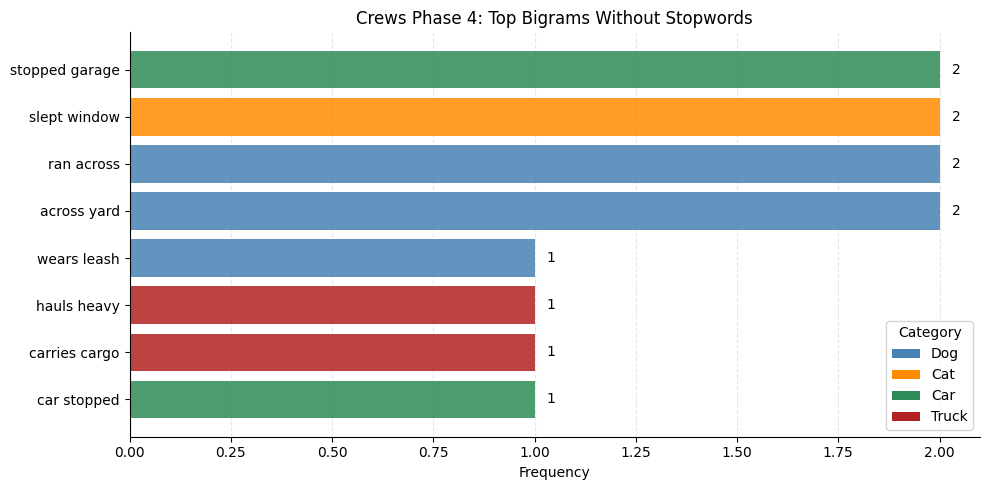

Saved bigram visualization to c:\Repos\nlp-03-text-exploration\docs\images\nlp_corpus_explore_crews_p4_top_bigrams.png


In [50]:
# Section 8 Python cell

# Bigrams combine each word with the next word in the text.
# This helps us capture local structure: how words are used together,
# not just which words appear individually.

bigrams_list: list[dict[str, str]] = []

for doc in corpus:
    tokens = [token for token in tokenize(doc["text"]) if token not in STOPWORDS]
    for i in range(len(tokens) - 1):
        bigrams_list.append(
            {
                "category": doc["category"],
                "bigram": f"{tokens[i]} {tokens[i + 1]}",
            }
        )

bigram_df: pl.DataFrame = pl.DataFrame(bigrams_list)

bigram_freq_df: pl.DataFrame = (
    bigram_df.group_by("bigram").len().sort("len", descending=True)
)

print("Top bigrams:")
print(bigram_freq_df.head(10))

dominant_bigram_category_df: pl.DataFrame = (
    bigram_df.group_by(["bigram", "category"])
    .len()
    .sort(["bigram", "len", "category"], descending=[False, True, False])
    .unique(subset=["bigram"], keep="first")
    .rename({"category": "dominant_category"})
    .select(["bigram", "dominant_category"])
)

top_bigram_plot_df = (
    bigram_freq_df.head(8)
    .join(dominant_bigram_category_df, on="bigram", how="left")
    .sort(["len", "bigram"])
)

bigram_category_colors = {
    "dog": "steelblue",
    "cat": "darkorange",
    "car": "seagreen",
    "truck": "firebrick",
}
bar_colors = [
    bigram_category_colors.get(category, "slategray")
    for category in top_bigram_plot_df["dominant_category"].to_list()
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    top_bigram_plot_df["bigram"].to_list(),
    top_bigram_plot_df["len"].to_list(),
    color=bar_colors,
    alpha=0.85,
)
ax.set_title("Crews Phase 4: Top Bigrams Without Stopwords")
ax.set_xlabel("Frequency")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for index, count in enumerate(top_bigram_plot_df["len"].to_list()):
    ax.text(count + 0.03, index, str(count), va="center")

legend_handles = [
    Patch(facecolor=color, label=category.title())
    for category, color in bigram_category_colors.items()
]
ax.legend(handles=legend_handles, title="Category", loc="lower right")

fig.tight_layout()
PLOTS_PATH.mkdir(parents=True, exist_ok=True)
fig.savefig(BIGRAM_PLOT_FILE_PATH, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved bigram visualization to {BIGRAM_PLOT_FILE_PATH}")

## Section 9. Visualize Token Frequencies

This chart is displayed inline in the notebook and also saved to `docs/images/nlp_corpus_explore_crews_p4_top_tokens.png`.

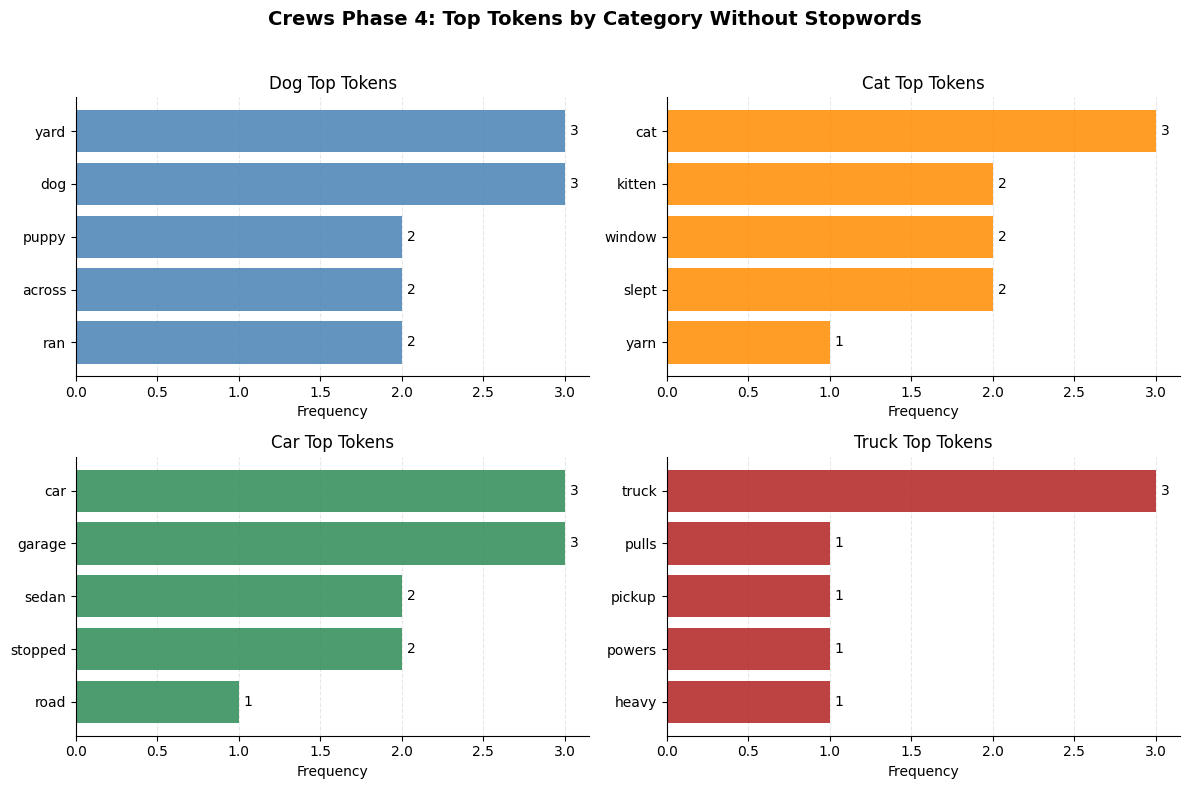

Saved visualization to c:\Repos\nlp-03-text-exploration\docs\images\nlp_corpus_explore_crews_p4_top_tokens.png


In [ ]:
# Section 9 Python cell

# Create a multi-panel figure so the chart compares all categories at once.
ordered_categories = ["dog", "cat", "car", "truck"]
category_colors = {
    "dog": "steelblue",
    "cat": "darkorange",
    "car": "seagreen",
    "truck": "firebrick",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for axis, category in zip(axes.flat, ordered_categories, strict=True):
    top_category_df = (
        category_freq_df.filter(pl.col("category") == category).head(5).sort("len")
    )
    tokens = top_category_df["token"].to_list()
    counts = top_category_df["len"].to_list()

    axis.barh(tokens, counts, color=category_colors[category], alpha=0.85)
    axis.set_title(f"{category.title()} Top Tokens")
    axis.set_xlabel("Frequency")
    axis.grid(axis="x", linestyle="--", alpha=0.3)
    axis.set_axisbelow(True)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    for index, count in enumerate(counts):
        axis.text(count + 0.03, index, str(count), va="center")

fig.suptitle(
    "Crews Phase 4: Top Tokens by Category Without Stopwords",
    fontsize=14,
    fontweight="bold",
)
fig.tight_layout(rect=(0, 0, 1, 0.96))

# Save the figure and also display it inline in the notebook.
PLOTS_PATH.mkdir(parents=True, exist_ok=True)
fig.savefig(PLOT_FILE_PATH, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved visualization to {PLOT_FILE_PATH}")

## Section 10. Interpret Results and Identify Patterns

In [52]:
# Section 10 Python cell

print("\nCASE GENERAL OBSERVATIONS:")
print("- Tokens cluster by category (dog, cat, car, truck).")
print("- Words that appear in similar contexts behave similarly.")
print("- Co-occurrence reveals contextual relationships between words.")
print("- Bigrams capture local structure beyond single tokens.")
print("- Patterns emerge before any machine learning is applied.")

print("\nCREWS PHASE 4 MODIFICATION:")
print(
    "- I removed common stopwords before computing token frequencies, co-occurrence, and bigrams."
)
print(
    "- I saved category and bigram comparison charts to docs/images instead of opening blocking chart windows."
)

print("\nCREWS SPECIFIC OBSERVATIONS:")
print(
    "- After stopword removal, category-specific terms like 'yard', 'garage', and 'truck' became more visible in the top rankings."
)
print(
    "- The updated chart makes it easier to compare the strongest tokens in each category side by side."
)
print(
    "- The filtered bigrams emphasize content pairs such as 'dog barks' and 'pickup pulls' instead of function-word combinations."
)
print(
    "- The bigram chart makes repeated word-pair patterns easier to scan than the table alone, and the legend clarifies which category each color represents."
)
print(
    "- Saving the plot to a file made the script easier to rerun because it now finishes without manual interaction."
)


CASE GENERAL OBSERVATIONS:
- Tokens cluster by category (dog, cat, car, truck).
- Words that appear in similar contexts behave similarly.
- Co-occurrence reveals contextual relationships between words.
- Bigrams capture local structure beyond single tokens.
- Patterns emerge before any machine learning is applied.

CREWS PHASE 4 MODIFICATION:
- I removed common stopwords before computing token frequencies, co-occurrence, and bigrams.
- I saved category and bigram comparison charts to docs/images instead of opening blocking chart windows.

CREWS SPECIFIC OBSERVATIONS:
- After stopword removal, category-specific terms like 'yard', 'garage', and 'truck' became more visible in the top rankings.
- The updated chart makes it easier to compare the strongest tokens in each category side by side.
- The filtered bigrams emphasize content pairs such as 'dog barks' and 'pickup pulls' instead of function-word combinations.
- The bigram chart makes repeated word-pair patterns easier to scan than th

In [53]:
# Final Python cell

LOG.info("========================")
LOG.info("Notebook executed successfully!")
LOG.info("========================")

print("Notebook executed successfully.")

2026-03-25 18:13:51 | INFO | CI | ========================
2026-03-25 18:13:51 | INFO | CI | Notebook executed successfully!
2026-03-25 18:13:51 | INFO | CI | ========================


Notebook executed successfully.
